In [ ]:
import pandas as pd
import os
import numpy as np

# Loading Data

In [ ]:
subfolder = '..'

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df_training = pd.read_csv('..\\Data\\Data used for model training (Corrected).csv',index_col='time',parse_dates=True)
df_validation = pd.read_csv('..\\Data\\Data used for model validation (Corrected).csv',index_col='time',parse_dates=True)

# Training XGB using 10-Fold-Cross Validation

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from bayes_opt import BayesianOptimization

In [ ]:
def ann_cv(X, y, n_splits=10, n_neurons=10, n_layers=1, learning_rate=0.01, epochs=10):
    kf = KFold(n_splits=n_splits, shuffle=False, random_state=None)
    val_scores = []
 
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)
 
    for train_index, test_index in kf.split(X):
        X_train, X_test = X_tensor[train_index], X_tensor[test_index]
        y_train, y_test = y_tensor[train_index], y_tensor[test_index]
 
        model = DynamicANN(input_features=X.shape[1], n_neurons=int(n_neurons), n_layers=int(n_layers))
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
       
        model.train()
        for epoch in range(int(epochs)):
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            optimizer.step()
       
        model.eval()
        with torch.no_grad():
            predictions = model(X_test)
            mse = mean_squared_error(y_test.numpy(), predictions.numpy())
            val_scores.append(mse)
   
    return -np.mean(val_scores)  # Negative because BayesianOptimization maximizes the objective function


In [ ]:
features = [
    #'V_G', 
    'P_eng', 
    'N_eng (S)', 
    'T_mean',
    'swh_hindcast',            # Replaces 'wave_height'
    'wave_dir_hindcast_head',  # Replaces 'rel_wave_direction'
    'wave_period_hindcast',    # Replaces 'wave_period'
    'wind_speed_hindcast',     # Replaces 'wind_speed'
    'wind_dir_hindcast_head',  # Replaces 'angle_wind_head'
    'current_speed',           # Calculated from utotal/vtotal
    'angle_current_head'       # Calculated relative current
]

# Preparation of X and y from your newly loaded dataframes
X = df_training[features].ffill().bfill()
y = df_training['V_G']

X_val = df_validation[features].ffill().bfill()
y_val = df_validation['V_G']

# Feature Importance

In [ ]:
X_test = df_validation[features] 
y_test = df_validation['V_G'] 

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from bayes_opt import BayesianOptimization

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
def model_xgb(n_estimators, max_depth, learning_rate, subsample, colsample_bytree, min_child_weight, gamma, reg_alpha, reg_lambda):
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('estimator', XGBRegressor(
            n_estimators=int(n_estimators),
            max_depth=int(max_depth),
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=min_child_weight,
            gamma=gamma,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            random_state=42,
            # --- FIXED FOR CPU ---
            tree_method='hist', 
            n_jobs=-1
        ))
    ])  
    return pipeline

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

In [ ]:
def objective_xgb(n_estimators, max_depth, learning_rate, subsample, colsample_bytree, min_child_weight, gamma, reg_alpha, reg_lambda, data, targets):
    model = XGBRegressor(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        eval_metric='rmse',
        random_state=42,
        tree_method='hist', # Efficient histogram-based method for CPU
        n_jobs=-1           # Use all CPU cores for each individual model fit
    )
    
    tscv = TimeSeriesSplit(n_splits=5) 
    # n_jobs=-1 here parallelizes the 5 cross-validation folds
    cv_scores = cross_val_score(model, data, targets, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
    return np.mean(cv_scores)

In [ ]:
pbounds_xgb = {
    'n_estimators': (100, 5000),
    'max_depth': (3, 15),
    'learning_rate': (0.01, 0.2),
    'subsample': (0.7, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'min_child_weight': (1.0, 5.0),
    'gamma': (0, 5),
    'reg_alpha': (0, 1),  # L1 regularization term on weights
    'reg_lambda': (0.1, 5.0)  # L2 regularization term on weights
}

In [ ]:
# Nested Cross-Validation
tscv_outer = TimeSeriesSplit(n_splits=3)

best_models = []
outer_scores = []

for train_idx, test_idx in tscv_outer.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[test_idx]

    optimizer = BayesianOptimization(
        f=lambda **params: objective_xgb(data=X_train, targets=y_train, **params),
        pbounds=pbounds_xgb,
        random_state=42,
        verbose=2
    )
    optimizer.maximize(init_points=10, n_iter=30)

    best_params = optimizer.max['params']
    best_params['n_estimators'] = int(best_params['n_estimators'])
    best_params['max_depth'] = int(best_params['max_depth'])

    model = model_xgb(**best_params)
    model.fit(X_train, y_train)
    best_models.append(model)

    pred = model.predict(X_test)
    score = mean_squared_error(y_test, pred)
    outer_scores.append(score)

best_model_index = np.argmin(outer_scores)
best_model = best_models[best_model_index]
best_score = outer_scores[best_model_index]

|   iter    |  target   | n_esti... | max_depth | learni... | subsample | colsam... | min_ch... |   gamma   | reg_alpha | reg_la... |
-------------------------------------------------------------------------------------------------------------------------------------
| 1         | -1.568217 | 1935.2465 | 14.408571 | 0.1490788 | 0.8795975 | 0.5780093 | 1.6239780 | 0.2904180 | 0.8661761 | 3.0454635 |
| 2         | -0.870449 | 3569.5556 | 3.2470139 | 0.1942828 | 0.9497327 | 0.6061695 | 1.7272998 | 0.9170225 | 0.3042422 | 2.6713065 |
| 3         | -0.662040 | 2216.5305 | 6.4947496 | 0.1262520 | 0.7418481 | 0.6460723 | 2.4654473 | 2.2803499 | 0.7851759 | 1.0784015 |
| 4         | -1.632240 | 2619.7487 | 10.108974 | 0.0188255 | 0.8822634 | 0.5852620 | 1.2602063 | 4.7444276 | 0.9656320 | 4.0611470 |
| 5         | -0.876700 | 1592.6074 | 4.1720653 | 0.1400042 | 0.8320457 | 0.5610191 | 2.9807076 | 0.1719426 | 0.9093204 | 1.3680219 |
| 6         | -1.357180 | 3346.3591 | 6.7405329 | 0.1088129 | 

In [ ]:
best_score

0.49394834118882613

In [ ]:
best_models[0].score(X_test,y_test)

0.7657520820844479

In [ ]:
best_models[1].score(X_test,y_test)

0.9019431437553982

In [ ]:
best_models[2].score(X_test,y_test)

0.929017962856303

In [ ]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [ ]:
xgb_model = best_model

In [ ]:
xgb_model.score(X,y)

0.9682571259337103

In [ ]:
xgb_model.score(X_test,y_test)

0.929017962856303

In [ ]:
from ipywidgets import interact, Dropdown
import cartopy.crs as ccrs
import cartopy
def update_plot(trip_no):
    trip_data = df_training[df_training['trip_no'] == trip_no]
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), subplot_kw={'projection': None})
    axs = axs.ravel()
    axs[0] = plt.subplot(2, 1, 1)
    
    # Normal plots
    axs[0].plot(trip_data['FCR'].values, label='FCR', color='red')
    axs[0].plot(xgb_model.predict(trip_data[features].values), '--', label='Prediction (Model 1)', color='blue')
    axs[0].set_title('Prediction Training Set', fontsize=16, fontweight='bold')
    axs[0].set_ylabel('$FCR$', fontsize=12)
    axs[0].legend()
    
    axs[1] = plt.subplot(2, 1, 2, projection=ccrs.PlateCarree())
    axs[1].coastlines(resolution='10m', color='black', linewidth=1) 
    axs[1].add_feature(cartopy.feature.LAND, edgecolor='black')
    axs[1].plot(trip_data['lon'].values, trip_data['lat'].values, transform=ccrs.Geodetic(), label='Route', color='black', linewidth=2)
    axs[1].plot(trip_data['lon'].iloc[0], trip_data['lat'].iloc[0], 'go', label='Departure', markersize=10)
    axs[1].plot(trip_data['lon'].iloc[-1], trip_data['lat'].iloc[-1], 'ro', label='Destination', markersize=10)
    axs[1].legend()

    axs[0].grid()
    axs[1].grid()
    
    plt.tight_layout()
    plt.show()

unique_trips = df_training['trip_no'].unique()
interact(update_plot, trip_no=unique_trips)
trip_dropdown = Dropdown(options=unique_trips, description='Select Trip:')



In [ ]:
def update_plot(trip_no):
    trip_data = df_validation[df_validation['trip_no'] == trip_no]
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), subplot_kw={'projection': None})
    axs = axs.ravel()
    axs[0] = plt.subplot(2, 1, 1)
    
    # Normal plots
    axs[0].plot(trip_data['FCR'].values, label='FCR', color='red')
    axs[0].plot(xgb_model.predict(trip_data[features].values), '--', label='Prediction (Model 1)', color='blue')
    axs[0].set_title('Prediction Validation Set', fontsize=16, fontweight='bold')
    axs[0].set_ylabel('$FCR$', fontsize=12)
    axs[0].legend()
    
    axs[1] = plt.subplot(2, 1, 2, projection=ccrs.PlateCarree())
    axs[1].coastlines(resolution='10m', color='black', linewidth=1) 
    axs[1].add_feature(cartopy.feature.LAND, edgecolor='black')
    axs[1].plot(trip_data['lon'].values, trip_data['lat'].values, transform=ccrs.Geodetic(), label='Route', color='black', linewidth=2)
    axs[1].plot(trip_data['lon'].iloc[0], trip_data['lat'].iloc[0], 'go', label='Departure', markersize=10)
    axs[1].plot(trip_data['lon'].iloc[-1], trip_data['lat'].iloc[-1], 'ro', label='Destination', markersize=10)
    axs[1].legend()

    axs[0].grid()
    axs[1].grid()
    
    plt.tight_layout()
    plt.show()

unique_trips_validation = df_validation['trip_no'].unique()
interact(update_plot, trip_no=unique_trips_validation)
trip_dropdown = Dropdown(options=unique_trips, description='Select Trip:')



interactive(children=(Dropdown(description='trip_no', options=(3, 15, 20, 36, 45, 57, 88, 93, 105, 108), value…

In [ ]:
y_xgb = xgb_model.predict(X)

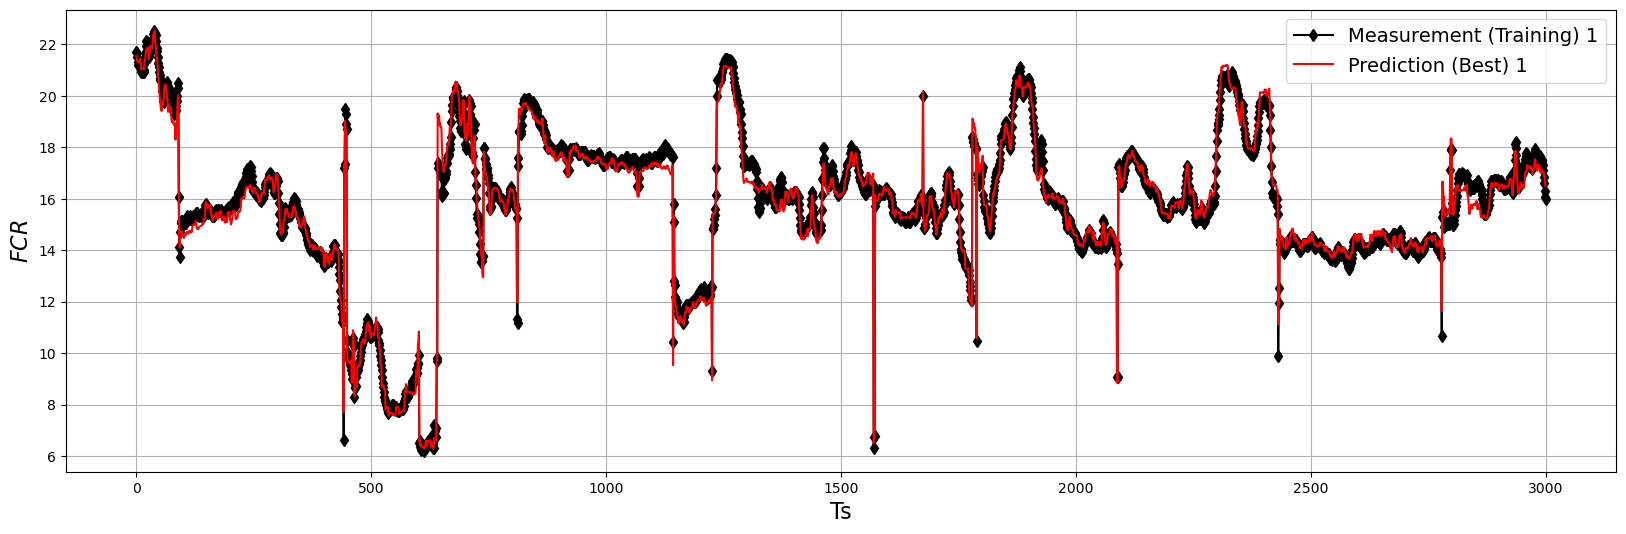

In [ ]:
plt.figure(figsize=(20,6))
start_ = 2801
finish_ = start_+3000
plt.plot(y.values[start_:finish_],'-d',color='black',label='Measurement (Training) 1')
plt.plot(y_xgb[start_:finish_],color='r',label='Prediction (Best) 1')
plt.xlabel('Ts',fontsize=16)
plt.ylabel('$FCR$',fontsize=16)
plt.legend(fontsize=14)
plt.grid()
plt.show()

In [ ]:
from joblib import dump

In [ ]:
dump(xgb_model,'..\\Models\\FCR_XGB_3Y_N_Eng_CV (Corrected).jb')

['..\\Models\\FCR_XGB_3Y_N_Eng_CV (New).jb']

In [ ]:
))

In [ ]:
pbounds = {
    'n_neurons': (50, 200),
    'n_layers': (1, 5),
    'learning_rate': (1e-4, 1e-1),
    'epochs': (50, 200)  
}

In [ ]:
def objective(n_neurons, n_layers, learning_rate, epochs):
    return ann_cv(X_scaled, y_scaled, n_splits=10, n_neurons=n_neurons, n_layers=n_layers, learning_rate=learning_rate, epochs=epochs)

# Run Bayesian Optimization
optimizer = BayesianOptimization(f=objective, pbounds=pbounds, random_state=1)
optimizer.maximize(init_points=3, n_iter=10)

In [ ]:
best_hyperparams = optimizer.max['params']
n_neurons = best_hyperparams['n_neurons']
n_layers = best_hyperparams['n_layers']
learning_rate = best_hyperparams['learning_rate']
epochs = best_hyperparams['epochs']

In [ ]:
best_hyperparams

In [ ]:
input_features = X.shape[1]

In [ ]:
best_model = DynamicANN(input_features=input_features, n_neurons=int(n_neurons), n_layers=int(n_layers))
criterion = nn.MSELoss()
optimizer = optim.Adam(best_model.parameters(), lr=learning_rate)
best_model.train()
for epoch in range(int(epochs)):
    optimizer.zero_grad()
    outputs = best_model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
X_tensor

In [ ]:
best_model.eval()  
with torch.no_grad():  
    predictions_tensor = best_model(X_tensor)
predictions_numpy = predictions_tensor.numpy()
predictions_original_scale = scalery.inverse_transform(predictions_numpy.reshape(-1, 1))



In [ ]:
y_true_numpy = y.values.reshape(-1, 1)
y_true_numpy

In [ ]:
r2 = r2_score(y_true_numpy, predictions_original_scale)
r2

In [ ]:
plt.figure(figsize=(20,6))
plt.plot(y_true_numpy[:5000],'D',color='k',label='Measurement (Training)')
plt.plot(predictions_original_scale[:5000],'--',color='r',label='Prediction (Training)')
plt.xlabel('Ts',fontsize=16)
plt.ylabel('V_G',fontsize=16)
plt.legend(fontsize=14)

In [ ]:
import seaborn as sns
sns.heatmap(df_new[features+['V_G']].corr(),annot=True)

In [ ]:
df0 = df_new.loc[df_new['trip_no']==20]
X0 = df0[features]
y0 = df0['V_G']
X_scaled0 = scalerX.transform(X0)
y_scaled0 = scalery.transform(y0.values.reshape(-1, 1))
X_tensor0 = torch.tensor(X_scaled0, dtype=torch.float32)
y_tensor0 = torch.tensor(y_scaled0, dtype=torch.float32).view(-1, 1)

best_model.eval()  
with torch.no_grad():  
    predictions_tensor0 = best_model(X_tensor0)
predictions_numpy0 = predictions_tensor0.numpy()
predictions_original_scale0 = scalery.inverse_transform(predictions_numpy0.reshape(-1, 1))

y0.values

r2 = r2_score(y0.values, predictions_original_scale0)
print(r2)

plt.plot(y0.values,label='Measurement (Unseen) 1')
plt.plot(predictions_original_scale0,label='Prediction (Unseen) 1')
plt.xlabel('Ts',fontsize=16)
plt.ylabel('V_G',fontsize=16)
plt.legend(fontsize=14)

In [ ]:
plt.plot(df_new['V_G'].values,df_new['P_eng'].values,'D')

In [ ]:
plt.plot(df0['V_G'].values,df0['P_eng'].values,'D')

In [ ]:
X2 = df_out_1[features]
y2 = df_out_1['V_G']
X_scaled2 = scalerX.transform(X2)
y_scaled2 = scalery.transform(y2.values.reshape(-1, 1))
X_tensor2 = torch.tensor(X_scaled2, dtype=torch.float32)
y_tensor2 = torch.tensor(y_scaled2, dtype=torch.float32).view(-1, 1)

best_model.eval()  
with torch.no_grad():  
    predictions_tensor2 = best_model(X_tensor2)
predictions_numpy2 = predictions_tensor2.numpy()
predictions_original_scale2 = scalery.inverse_transform(predictions_numpy2.reshape(-1, 1))

y2.values

r2 = r2_score(y2.values, predictions_original_scale2)
r2

In [ ]:
plt.plot(y2,label='Measurement (Unseen) 1')
plt.plot(predictions_original_scale2,label='Prediction (Unseen) 1')
plt.xlabel('Ts',fontsize=16)
plt.ylabel('V_G',fontsize=16)
plt.legend(fontsize=14)

In [ ]:
X3 = df_out_2[features]
y3 = df_out_2['V_G']
X_scaled3 = scalerX.transform(X3)
y_scaled3 = scalery.transform(y3.values.reshape(-1, 1))
X_tensor3 = torch.tensor(X_scaled3, dtype=torch.float32)
y_tensor3 = torch.tensor(y_scaled3, dtype=torch.float32).view(-1, 1)

best_model.eval()  
with torch.no_grad():  
    predictions_tensor3 = best_model(X_tensor3)
predictions_numpy3 = predictions_tensor3.numpy()
predictions_original_scale3 = scalery.inverse_transform(predictions_numpy3.reshape(-1, 1))


r2 = r2_score(y3.values, predictions_original_scale3)
r2

In [ ]:
plt.plot(y3,label='Measurement (Unseen) 2')
plt.plot(predictions_original_scale3,label='Prediction (Unseen) 2')
plt.xlabel('Ts',fontsize=16)
plt.ylabel('V_G',fontsize=16)
plt.legend(fontsize=14)

In [ ]:
plt.plot(df_new['V_G'])

In [ ]:
plt.plot(df_new['P_eng'])